# Task 2: Fully Convolutional Network (FCN)

Implement an FCN for semantic segmentation, train it on a small dataset, and analyze how architectural and training choices affect performance.

**Instructions:**

**Dataset**:
- Use a subset of Pascal VOC, COCO, or a small custom dataset (10–20 images for quick runs).
- Split into train/test.
- Preprocess (resize, normalize, and convert masks to class indices).
**Model Implementation**:
- Implement FCN-32s, FCN-16s, or FCN-8s variants.
- Use pretrained ResNet/VGG (remove final FC layers) as a backbone
- Upsampling Method: 1) transpose convolution vs 2) bilinear interpolation.
**Training**
- Loss: CrossEntropyLoss
- Optimizer: Adam or SGD
- Metrics: Mean IoU, pixel accuracy
- Train for 20 epochs (or until convergence).
- Log training curves.

**Deliverable:**

- Jupyter notebook with clear code and comments.
- Visualization of segmentation results (min. 3 test images).
- Table comparing transpose convolution vs bilinear interpolation.
- Summarize with visuals and short analysis.

In [1]:
import os
import random
import copy
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import pandas as pd

import torchvision
from torchvision.datasets import VOCSegmentation
from torchvision import transforms, models
from torchvision.transforms import functional as TF
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMAGE_SIZE = 224
NUM_CLASSES = 21
IGNORE_INDEX = 255
BATCH_SIZE = 2
EPOCHS = 30
LEARNING_RATE = 1e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Using device: cuda


### Dataset
> https://www.kaggle.com/datasets/gopalbhattrai/pascal-voc-2012-dataset

In [2]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=128, is_train=True):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.img_size = img_size
        self.is_train = is_train

        img_paths = sorted(list(self.image_dir.glob("*.jpg")))
        mask_paths = sorted(list(self.mask_dir.glob("*.png")))

        img_stems = {p.stem for p in img_paths}
        mask_stems = {p.stem for p in mask_paths}
        common = sorted(list(img_stems & mask_stems))

        self.image_paths = [self.image_dir / f"{s}.jpg" for s in common]
        self.mask_paths  = [self.mask_dir / f"{s}.png" for s in common]

        assert len(self.image_paths) == len(self.mask_paths), "Image/mask count mismatch"

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),])

        self.mask_resize = transforms.Resize(
            (img_size, img_size),
            interpolation=transforms.InterpolationMode.NEAREST)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx])

        # optional augmentation
        if self.is_train and np.random.rand() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        img = self.img_transform(img)
        mask = self.mask_resize(mask)
        mask = np.array(mask, dtype=np.int64)  # class index map
        mask = torch.from_numpy(mask)

        return img, mask

In [3]:
images_dir = "data/task2/images/JPEGImages"
masks_dir  = "data/task2/masks/SegmentationClass"

full_dataset = SegmentationDataset(images_dir, masks_dir, IMAGE_SIZE)
print("Total samples in full_dataset:", len(full_dataset))

Total samples in full_dataset: 2913


### Create Train / Validation Dataloaders

In [4]:
full_dataset = SegmentationDataset(images_dir,masks_dir,img_size=IMAGE_SIZE,is_train=True)
n_total = len(full_dataset)
n_train = max(1, int(0.8 * n_total))
n_val   = n_total - n_train

train_ds, val_ds = random_split(full_dataset,[n_train, n_val],generator=torch.Generator().manual_seed(SEED))

train_ds.dataset.is_train = True
val_ds.dataset.is_train = False

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,num_workers=2, pin_memory=(device.type == "cuda"))

print("Total samples:", n_total)
print("Train samples:", len(train_ds))
print("Val samples  :", len(val_ds))

Total samples: 2913
Train samples: 2330
Val samples  : 583


### Check one sample (image + multi-class mask)

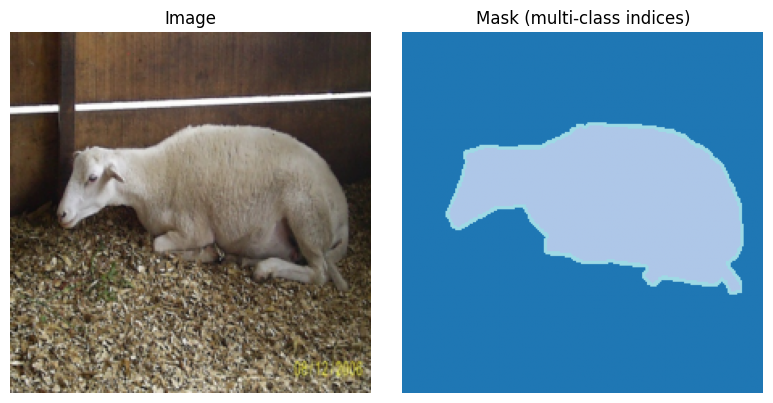

In [5]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3,1,1)
    std  = torch.tensor(std).view(3,1,1)
    img = img_tensor * std + mean
    return img.clamp(0,1)

img, mask = full_dataset[42]
img_show = denormalize(img).permute(1,2,0).cpu().numpy()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_show)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask.numpy(), cmap="tab20")  # multi-class
plt.title("Mask (multi-class indices)")
plt.axis("off")

plt.tight_layout()
plt.show()

### Model Implementation (FCN-8s ResNet Model)

In [6]:
class FCN8sResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, upsampling="deconv", freeze_backbone=True):
        super().__init__()
        assert upsampling in ["deconv", "bilinear"]
        self.upsampling = upsampling

        try:
            resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        except Exception:
            resnet = models.resnet18(pretrained=True)

        self.initial = nn.Sequential(resnet.conv1,resnet.bn1,resnet.relu,resnet.maxpool)
        self.layer1 = resnet.layer1   
        self.layer2 = resnet.layer2   
        self.layer3 = resnet.layer3   
        self.layer4 = resnet.layer4   

        if freeze_backbone:
            for m in [self.initial, self.layer1, self.layer2, self.layer3, self.layer4]:
                for p in m.parameters():
                    p.requires_grad = False

        ch2, ch3, ch4 = 128, 256, 512

        self.score_layer4 = nn.Conv2d(ch4, num_classes, kernel_size=1)
        self.score_layer3 = nn.Conv2d(ch3, num_classes, kernel_size=1)
        self.score_layer2 = nn.Conv2d(ch2, num_classes, kernel_size=1)

        if upsampling == "deconv":
            self.upscore2_1 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1, bias=False)
            self.upscore2_2 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1, bias=False)
            self._init_upsampling(self.upscore2_1)
            self._init_upsampling(self.upscore2_2)

    @staticmethod
    def _init_upsampling(m):
        if not isinstance(m, nn.ConvTranspose2d):
            return
        w = m.weight.data
        f = np.ceil(w.size(2) / 2)
        c = (2 * f - 1 - f % 2) / (2.0 * f)
        for i in range(w.size(2)):
            for j in range(w.size(3)):
                w[0,0,i,j] = (1 - abs(i / f - c)) * (1 - abs(j / f - c))
        for ch in range(1, w.size(0)):
            w[ch,0,:,:] = w[0,0,:,:]

    def forward(self, x):
        input_size = x.shape[2:]

        x = self.initial(x)
        x1 = self.layer1(x)   
        x2 = self.layer2(x1) 
        x3 = self.layer3(x2)  
        x4 = self.layer4(x3) 

        s4 = self.score_layer4(x4)
        s3 = self.score_layer3(x3)
        s2 = self.score_layer2(x2)

        if self.upsampling == "deconv":
            up4 = self.upscore2_1(s4)
            if up4.size(2) != s3.size(2) or up4.size(3) != s3.size(3):
                up4 = up4[:, :, :s3.size(2), :s3.size(3)]
            fuse3 = up4 + s3

            up3 = self.upscore2_2(fuse3)
            if up3.size(2) != s2.size(2) or up3.size(3) != s2.size(3):
                up3 = up3[:, :, :s2.size(2), :s2.size(3)]
            fuse2 = up3 + s2
        else:
            up4 = F.interpolate(s4, size=s3.shape[2:], mode="bilinear", align_corners=False)
            fuse3 = up4 + s3
            up3 = F.interpolate(fuse3, size=s2.shape[2:], mode="bilinear", align_corners=False)
            fuse2 = up3 + s2

        out = F.interpolate(fuse2, size=input_size, mode="bilinear", align_corners=False)
        return out


m_demo = FCN8sResNet(num_classes=NUM_CLASSES, upsampling="deconv").to(device)
x_demo = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
y_demo = m_demo(x_demo)
print("Demo output shape:", y_demo.shape)

Demo output shape: torch.Size([1, 21, 224, 224])


### Metrics: Pixel Accuracy & Mean IoU

In [7]:
def pixel_accuracy(pred, target, ignore_index=255):
    mask = (target != ignore_index)
    if mask.sum() == 0:
        return 0.0
    
    correct = (pred[mask] == target[mask]).sum().item()
    total   = mask.sum().item()
    return correct / total

def mean_iou(pred, target, num_classes=21, ignore_index=255):
    
    pred   = pred.view(-1)
    target = target.view(-1)

    mask = (target != ignore_index)
    pred   = pred[mask]
    target = target[mask]

    ious = []

    for cls in range(num_classes):
        pred_i   = (pred == cls)
        target_i = (target == cls)

        inter = (pred_i & target_i).sum().item()
        union = (pred_i | target_i).sum().item()

        if union == 0:
            continue

        ious.append(inter / union)

    return float(np.mean(ious)) if ious else 0.0

### Training Loop

In [8]:
def train_segmentation(model,train_loader,val_loader,num_epochs=EPOCHS,lr=1e-4,num_classes=NUM_CLASSES,title="Model",):
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_miou": []}

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for imgs, masks in train_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device, dtype=torch.long)

            logits = model(imgs)
            loss   = criterion(logits, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        val_acc  = 0.0
        val_miou = 0.0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(device)
                masks = masks.to(device, dtype=torch.long)

                logits = model(imgs)
                loss   = criterion(logits, masks)
                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)

                val_acc  += pixel_accuracy(preds, masks, ignore_index=IGNORE_INDEX)
                val_miou += mean_iou(preds, masks, num_classes=num_classes, ignore_index=IGNORE_INDEX)

        val_loss /= len(val_loader)
        val_acc  /= len(val_loader)
        val_miou /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_miou"].append(val_miou)

        print(f"[{title}] Epoch {epoch+1}/{num_epochs} "f"train={train_loss:.3f} val={val_loss:.3f} "f"acc={val_acc:.3f} mIoU={val_miou:.3f}")

    return model, history
      

### Train Models

In [9]:
model_transpose = FCN8sResNet(num_classes=NUM_CLASSES, upsampling="deconv")
model_transpose, hist_transpose = train_segmentation(model_transpose, train_loader, val_loader,num_epochs=EPOCHS, lr=1e-4, num_classes=NUM_CLASSES, title="Transpose")

model_bilinear = FCN8sResNet(num_classes=NUM_CLASSES, upsampling="bilinear")
model_bilinear, hist_bilinear = train_segmentation(model_bilinear, train_loader, val_loader,num_epochs=EPOCHS, lr=1e-4, num_classes=NUM_CLASSES, title="Bilinear")

[Transpose] Epoch 1/30 train=1.290 val=1.093 acc=0.735 mIoU=0.142
[Transpose] Epoch 2/30 train=1.097 val=0.992 acc=0.758 mIoU=0.174
[Transpose] Epoch 3/30 train=1.022 val=0.885 acc=0.772 mIoU=0.164
[Transpose] Epoch 4/30 train=0.954 val=0.823 acc=0.780 mIoU=0.194
[Transpose] Epoch 5/30 train=0.927 val=0.796 acc=0.786 mIoU=0.200
[Transpose] Epoch 6/30 train=0.899 val=0.736 acc=0.795 mIoU=0.217
[Transpose] Epoch 7/30 train=0.870 val=0.708 acc=0.806 mIoU=0.245
[Transpose] Epoch 8/30 train=0.846 val=0.706 acc=0.805 mIoU=0.256
[Transpose] Epoch 9/30 train=0.816 val=0.664 acc=0.812 mIoU=0.272
[Transpose] Epoch 10/30 train=0.795 val=0.634 acc=0.822 mIoU=0.287
[Transpose] Epoch 11/30 train=0.776 val=0.667 acc=0.810 mIoU=0.267
[Transpose] Epoch 12/30 train=0.760 val=0.664 acc=0.814 mIoU=0.274
[Transpose] Epoch 13/30 train=0.760 val=0.614 acc=0.828 mIoU=0.294
[Transpose] Epoch 14/30 train=0.742 val=0.599 acc=0.829 mIoU=0.307
[Transpose] Epoch 15/30 train=0.733 val=0.617 acc=0.826 mIoU=0.311
[Tra

### Plot Training Curves and Visualization of segmentation results

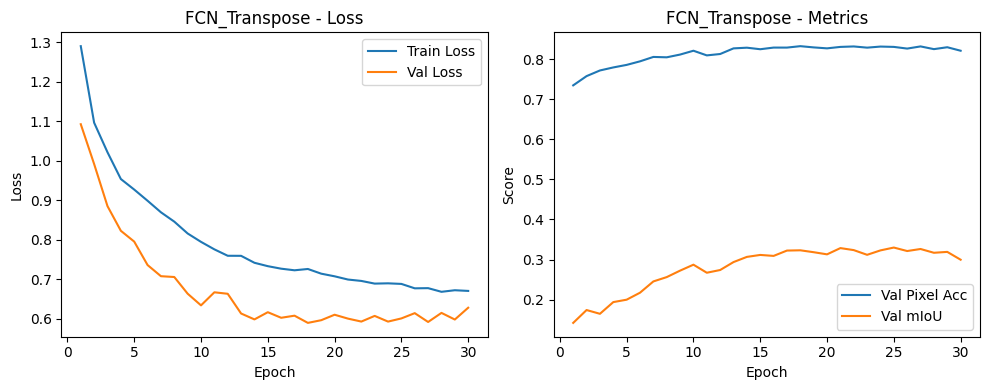

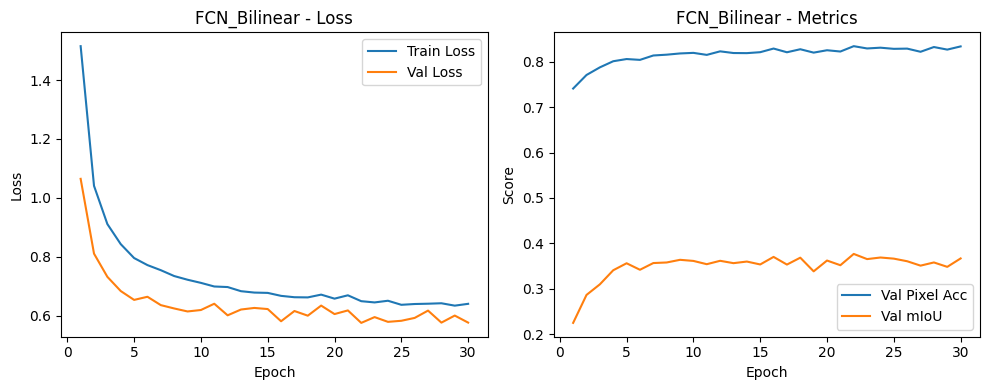

In [10]:
def plot_history(history, title="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history["val_acc"],  label="Val Pixel Acc")
    plt.plot(epochs, history["val_miou"], label="Val mIoU")
    plt.xlabel("Epoch"); plt.ylabel("Score")
    plt.title(f"{title} - Metrics")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(hist_transpose, "FCN_Transpose")
plot_history(hist_bilinear, "FCN_Bilinear")

In [11]:
def voc_colormap(N=21):
    np.random.seed(0)
    colors = np.random.randint(0, 255, size=(N, 3), dtype=np.uint8)
    colors[0] = np.array([0, 0, 0])  # background = black
    return colors
    
def unnormalize(img_tensor):
    img = img_tensor.clone().permute(1,2,0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

def visualize_samples(model, dataset, n_samples=3, title="Model"):
    model.eval()
    cmap = voc_colormap(NUM_CLASSES)
    idxs = np.random.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    for idx in idxs:
        img, mask = dataset[idx]              
        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(device))
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        img_np = unnormalize(img)

        mask_rgb = cmap[mask.numpy().clip(0, NUM_CLASSES-1)]
        pred_rgb = cmap[pred.clip(0, NUM_CLASSES-1)]

        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(img_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(mask_rgb)
        plt.title("Ground Truth Mask")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(pred_rgb)
        plt.title(f"{title} Prediction")
        plt.axis("off")

        plt.show()

FCN_Transpose predictions:


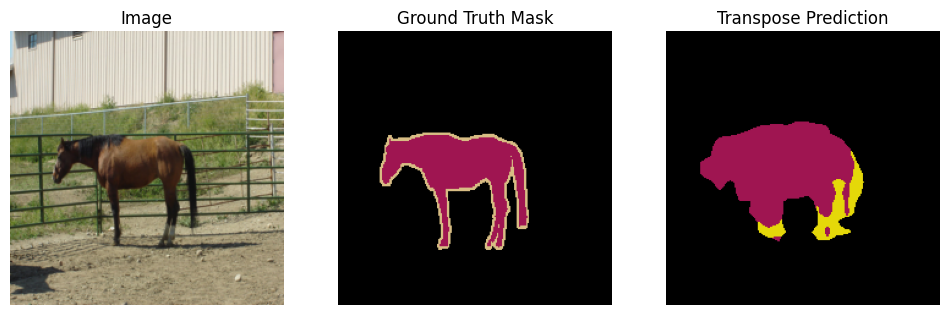

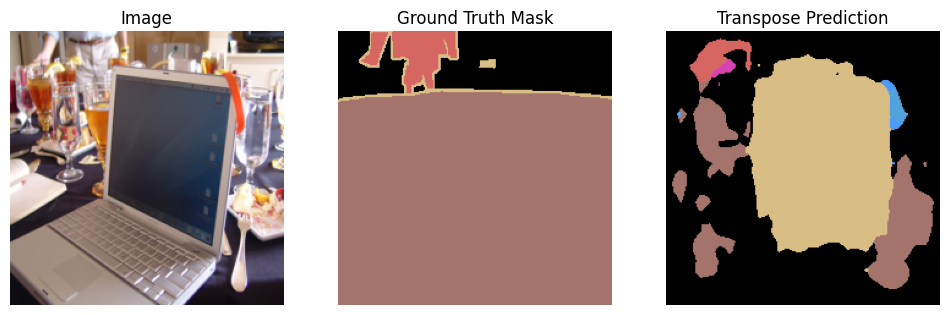

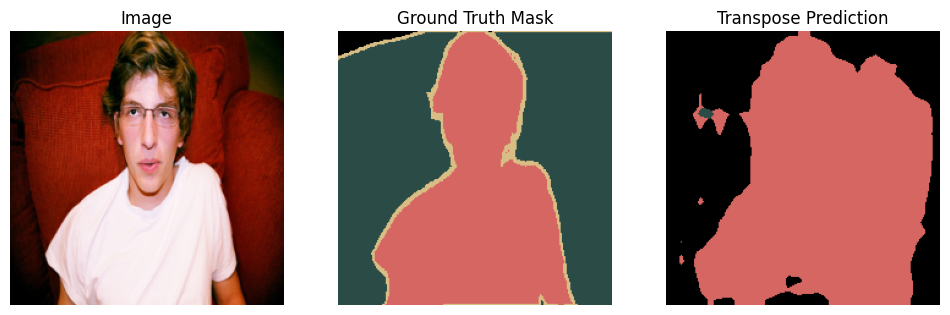

----------------------------------------------------------------------------------------------------
FCN_Bilinear predictions:


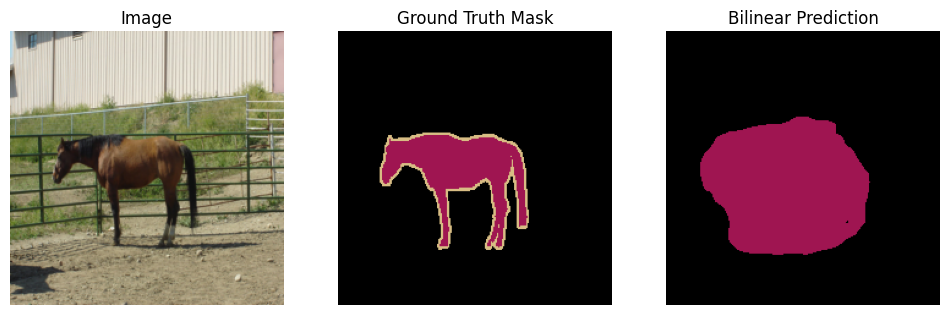

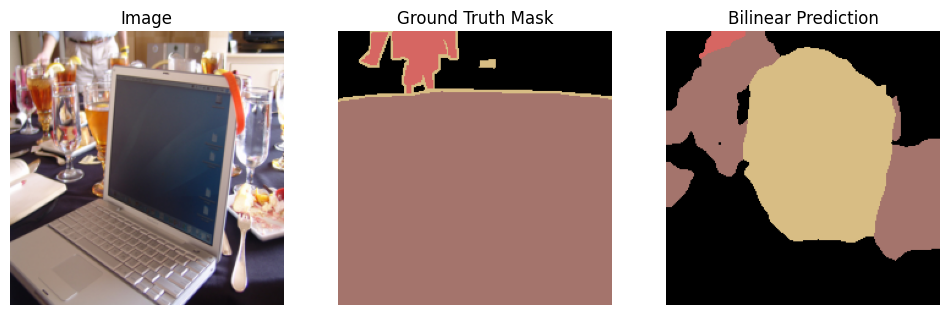

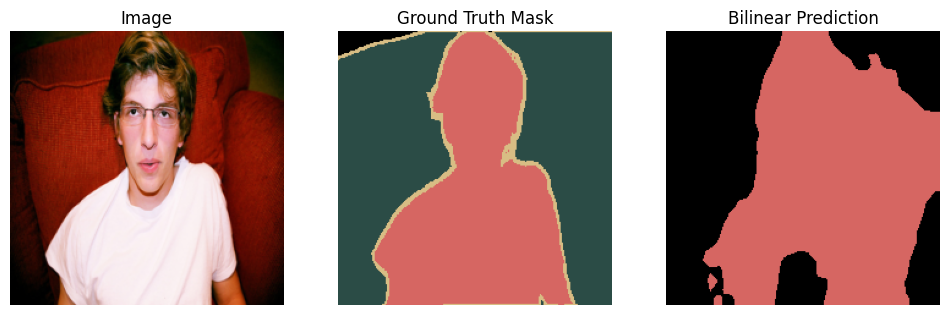

In [12]:
print("FCN_Transpose predictions:")
visualize_samples(model_transpose, val_ds, n_samples=3, title="Transpose")
print("-"*100)
print("FCN_Bilinear predictions:")
visualize_samples(model_bilinear, val_ds, n_samples=3, title="Bilinear")

In [13]:
compare_df = pd.DataFrame({"Model": ["FCN_Transpose", "FCN_Bilinear"],"Val Pixel Acc": [hist_transpose["val_acc"][-1], hist_bilinear["val_acc"][-1]],
    "Val mIoU": [hist_transpose["val_miou"][-1], hist_bilinear["val_miou"][-1]],})

compare_df = compare_df.sort_values("Val mIoU", ascending=False).reset_index(drop=True)
compare_df.style.format({"Val Pixel Acc": "{:.4f}","Val mIoU": "{:.4f}"})

,Model,Val Pixel Acc,Val mIoU
0,FCN_Bilinear,0.8339,0.3667
1,FCN_Transpose,0.8218,0.2995


### **Short analysis**
FCN-Bilinear outperformed FCN-Transpose in this experiment. While both models achieved comparable pixel accuracy (~0.83 vs. ~0.82), FCN-Bilinear obtained a significantly higher mIoU (0.3667 vs. 0.2995), indicating better segmentation quality and more accurate object boundaries. Its predictions were smoother and more stable overall.

In contrast, FCN-Transpose produced sharper edges but suffered from checkerboard artifacts, leading to inconsistent and noisier segmentation, especially around object boundaries.

Overall, bilinear interpolation provided a more reliable and visually cleaner upsampling method, making FCN-Bilinear the better-performing model for this FCN-8s segmentation task.